# Week 06 : Cost Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor

1.<br>Create the following data set for Experience and Salary in CSV. Applying SLR, explore the relationship between
salary and experience with experience in x-axis and salary in y axis.
<br>a. Check for various values of beta (slope) = 0.1, 1.5, and 0.8 with a fixed value of intercept i.e b=1.1. Plot the graph
between beta and mean squared error(MSE) for each case.
<br>b. Try with beta between 0 to 1.5 with an increment of 0.01 keeping b (intercept) as constant and Plot the graph between
beta and mean squared error(MSE).
<br>c. Try with different values of intercept for slope beta between 0 to 1.5 with an increment of 0.01. Plot the graph between
beta and mean squared error(MSE).
<br>d. Use the scikit learn and compare the results of MSE

CSV file 'salary_data.csv' created successfully.
    salary  experience
0      1.7         1.2
1      2.4         1.5
2      2.3         1.9
3      3.1         2.2
4      3.7         2.4
5      4.2         2.5
6      4.4         2.8
7      6.1         3.1
8      5.4         3.3
9      5.7         3.7
10     6.4         4.2
11     6.2         4.4


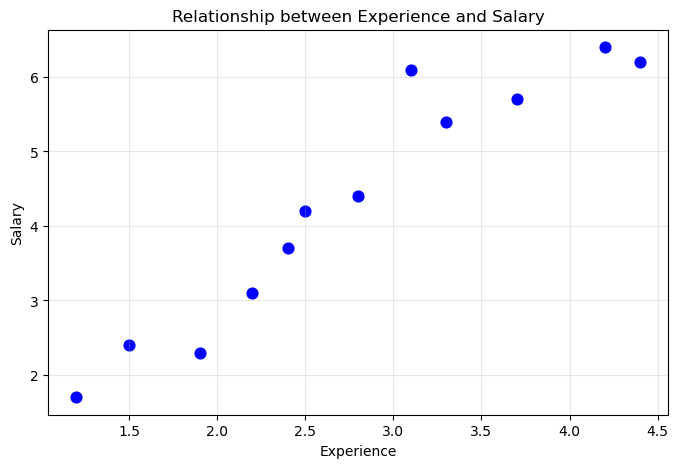

In [2]:
data = {
    'salary': [1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2],
    'experience': [1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4]
}
df = pd.DataFrame(data)
df.to_csv('salary_data.csv', index=False)
print("CSV file 'salary_data.csv' created successfully.")
print(df)
X = df['experience'].values
y = df['salary'].values


plt.figure(figsize=(8, 5))

plt.scatter(X, y, color='blue', s=60)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Relationship between Experience and Salary")
plt.grid(True, alpha=0.3)

plt.show()

Fixed intercept b = 1.1
Beta = 0.1, MSE = 10.811150
Beta = 1.5, MSE = 1.140417
Beta = 0.8, MSE = 1.762600


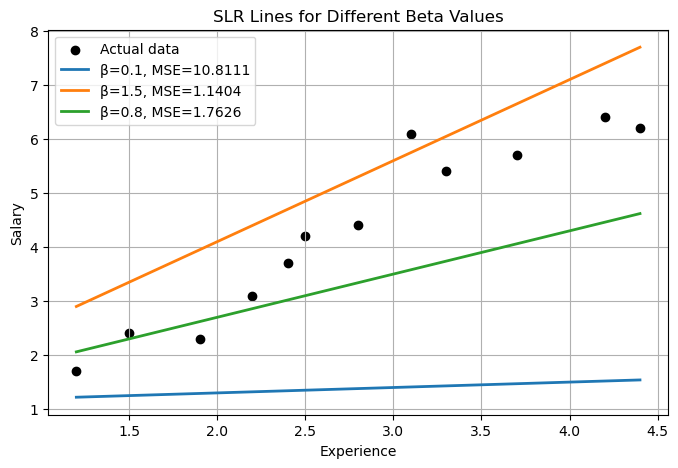

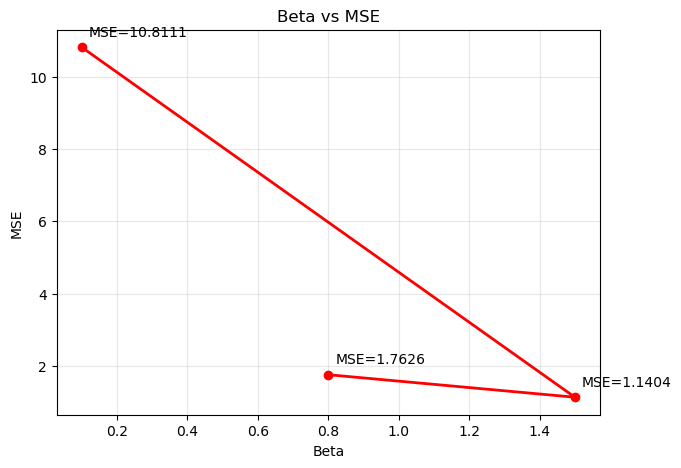

In [3]:
# A
# beta = 0.1, 1.5 and 0.8
# b = 1.1

b = 1.1
betas_a = [0.1, 1.5, 0.8]

print("Fixed intercept b =", b)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Actual data')

for beta in betas_a:
    y_pred = beta * X + b
    mse = np.mean((y - y_pred) ** 2)
    print(f"Beta = {beta:.1f}, MSE = {mse:.6f}")
    plt.plot(X,y_pred,linewidth=2,label=f"β={beta}, MSE={mse:.4f}")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("SLR Lines for Different Beta Values")
plt.legend()
plt.grid(True)

plt.show()


# beta vs MSE
mse_a = []
for beta in betas_a:
    y_pred = beta * X + b
    mse = np.mean((y - y_pred) ** 2)
    mse_a.append(mse)

plt.figure(figsize=(7, 5))

plt.plot(betas_a,mse_a,marker='o',linewidth=2,color='red')

for beta, mse in zip(betas_a, mse_a):
    plt.annotate(
        f"MSE={mse:.4f}",
        (beta, mse),
        xytext=(5, 8),
        textcoords="offset points"
    )

plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE")
plt.grid(True, alpha=0.3)

plt.show()

Best beta in the range 0 to 1.5 = 1.20
Minimum MSE = 0.375267


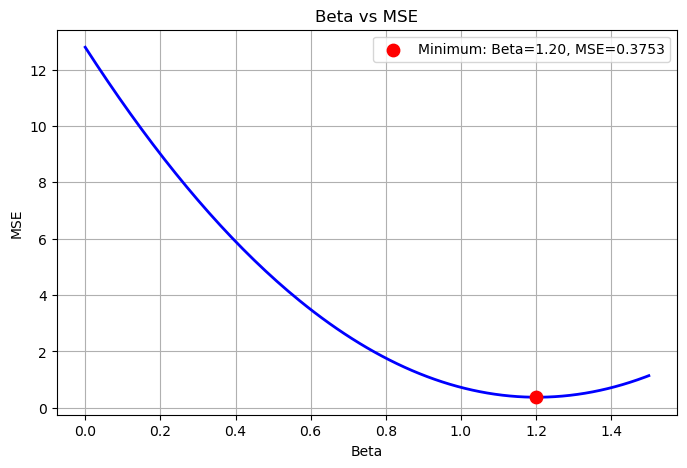

In [4]:
#B
# beta from 0 to 1.5 with increment 0.01
# b = 1.1

b = 1.1

beta_values = np.arange(0, 1.5 + 0.01, 0.01)
mse_values = []

for beta in beta_values:

    y_pred = beta * X + b
    mse = np.mean((y - y_pred) ** 2)

    mse_values.append(mse)

mse_values = np.array(mse_values)

# Find beta producing minimum MSE
best_index = np.argmin(mse_values)
best_beta = beta_values[best_index]
best_mse = mse_values[best_index]

print(f"Best beta in the range 0 to 1.5 = {best_beta:.2f}")
print(f"Minimum MSE = {best_mse:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(beta_values,mse_values,color='blue',linewidth=2)
plt.scatter(best_beta,best_mse,color='red',s=80,zorder=5,
    label=f"Minimum: Beta={best_beta:.2f}, MSE={best_mse:.4f}"
)

plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE")
plt.legend()
plt.grid(True)
plt.show()

Intercept = 0.0, Best beta = 1.50, Minimum MSE = 0.260417
Intercept = 0.4, Best beta = 1.42, Minimum MSE = 0.256459
Intercept = 0.7, Best beta = 1.33, Minimum MSE = 0.291582
Intercept = 1.7, Best beta = 1.02, Minimum MSE = 0.553053
Intercept = 2.6, Best beta = 0.72, Minimum MSE = 0.996243


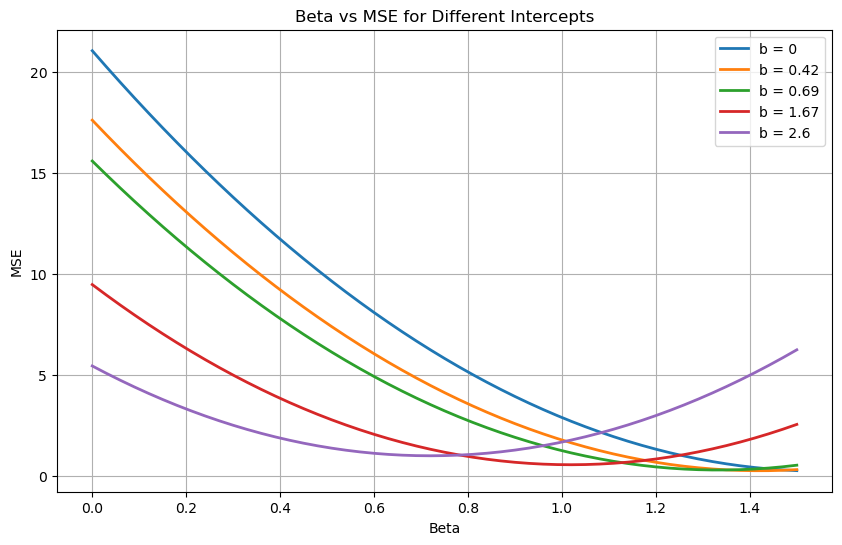

In [5]:
#C
#beta = 0 to 1.5 with increment 0.01

intercepts = [0, 0.42, 0.69, 1.67, 2.60]
plt.figure(figsize=(10, 6))

for b in intercepts:
    mse_for_b = []
    for beta in beta_values:
        y_pred = beta * X + b
        mse = np.mean((y - y_pred) ** 2)
        mse_for_b.append(mse)
    mse_for_b = np.array(mse_for_b)

    idx = np.argmin(mse_for_b)
    print(
        f"Intercept = {b:.1f}, "
        f"Best beta = {beta_values[idx]:.2f}, "
        f"Minimum MSE = {mse_for_b[idx]:.6f}")

    plt.plot(beta_values,mse_for_b,linewidth=2,label=f"b = {b}")

plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE for Different Intercepts")
plt.legend()
plt.grid(True)

plt.show()

Beta     = 1.567098
Intercept= -0.035639
MSE      = 0.233667


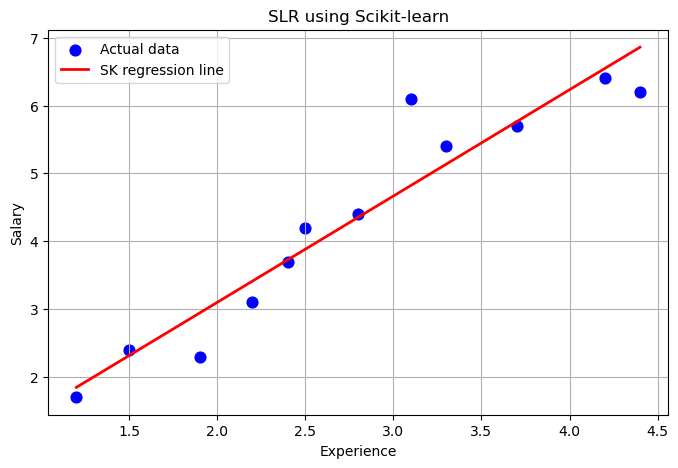

In [6]:
#D
# Scikit-learn Linear Regression

X_sklearn = X.reshape(-1, 1)
model = LinearRegression()
model.fit(X_sklearn, y)
sklearn_beta = model.coef_[0]
sklearn_b = model.intercept_

y_pred_sklearn = model.predict(X_sklearn)

sklearn_mse = mean_squared_error(y, y_pred_sklearn)

print(f"Beta     = {sklearn_beta:.6f}")
print(f"Intercept= {sklearn_b:.6f}")
print(f"MSE      = {sklearn_mse:.6f}")


plt.figure(figsize=(8, 5))

plt.scatter(X,y,color='blue',s=60,label='Actual data')

plt.plot(X,y_pred_sklearn,color='red',linewidth=2,label='SK regression line')

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("SLR using Scikit-learn")
plt.legend()
plt.grid(True)
plt.show()

2.<br>
Apply Stochastic Gradient Descent for the afore-mentioned dataset, and arrive at different values of B0, B1
and error for 60 iterations of 5 epochs.
<br>a. Plot the graph of log loss/error versus iteration.
<br>b.Use the scikit learn and arrive at the results of B0, B1 and error, for 60 iterations of 5 epochs.
<br>c. Plot the graph between beta (X-axis) and log loss/ error (Y-axis) using scikit learn and your approach
separately.
<br>d. Plot the separate graph of –log(x) ( y=1 case) and –log(1-x) (y=0 case) and also draw the combined graph of
both cases.

In [17]:
# ============================================================
# PART 1: MANUAL STOCHASTIC GRADIENT DESCENT
# ============================================================
learning_rate = 0.01

B0 = 0.0
B1 = 0.0

epochs = 5
iterations_per_epoch = 60

# Store results
iteration_history = []
epoch_history = []
B0_history = []
B1_history = []
error_history = []

iteration_number = 0

np.random.seed(42)

for epoch in range(epochs):

    # Shuffle data at the beginning of every epoch
    indices = np.random.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(iterations_per_epoch):

        iteration_number += 1

        # Select one random training example
        index = i % len(X)

        xi = X_shuffled[index]
        yi = y_shuffled[index]

        # Prediction
        y_pred = B0 + B1 * xi

        # Error for selected observation
        error = yi - y_pred

        # Gradients
        dB0 = -2 * error
        dB1 = -2 * error * xi

        # Update parameters
        B0 = B0 - learning_rate * dB0
        B1 = B1 - learning_rate * dB1

        # Calculate MSE on complete dataset
        predictions = B0 + B1 * X

        mse = np.mean((y - predictions) ** 2)

        iteration_history.append(iteration_number)
        epoch_history.append(epoch + 1)
        B0_history.append(B0)
        B1_history.append(B1)
        error_history.append(mse)



results = pd.DataFrame({
    'Iteration': iteration_history,
    'Epoch': epoch_history,
    'B0': B0_history,
    'B1': B1_history,
    'MSE': error_history
})

print("\n========================================")
print("MANUAL STOCHASTIC GRADIENT DESCENT")
print("========================================")

print(results.to_string(index=False))

print("\nFinal Manual SGD Results:")
print(f"B0 = {B0:.6f}")
print(f"B1 = {B1:.6f}")
print(f"MSE = {error_history[-1]:.6f}")


MANUAL STOCHASTIC GRADIENT DESCENT
 Iteration  Epoch       B0       B1      MSE
         1      1 0.128000 0.537600 8.441355
         2      1 0.199658 0.802733 4.317461
         3      1 0.210399 0.815623 4.126751
         4      1 0.260360 0.980494 2.319236
         5      1 0.290128 1.054914 1.672165
         6      1 0.290239 1.055124 1.670450
         7      1 0.300780 1.070937 1.539938
         8      1 0.324522 1.175401 0.901987
         9      1 0.335612 1.202018 0.767543
        10      1 0.376375 1.328382 0.349175
        11      1 0.372399 1.319634 0.367984
        12      1 0.379051 1.338261 0.330805
        13      1 0.387056 1.371882 0.283421
        14      1 0.391796 1.389419 0.267580
        15      1 0.384614 1.380800 0.275484
        16      1 0.393789 1.411078 0.256649
        17      1 0.399359 1.425003 0.254478
        18      1 0.383222 1.394343 0.265329
        19      1 0.381727 1.392101 0.267035
        20      1 0.375588 1.365087 0.293993
        21      1 0

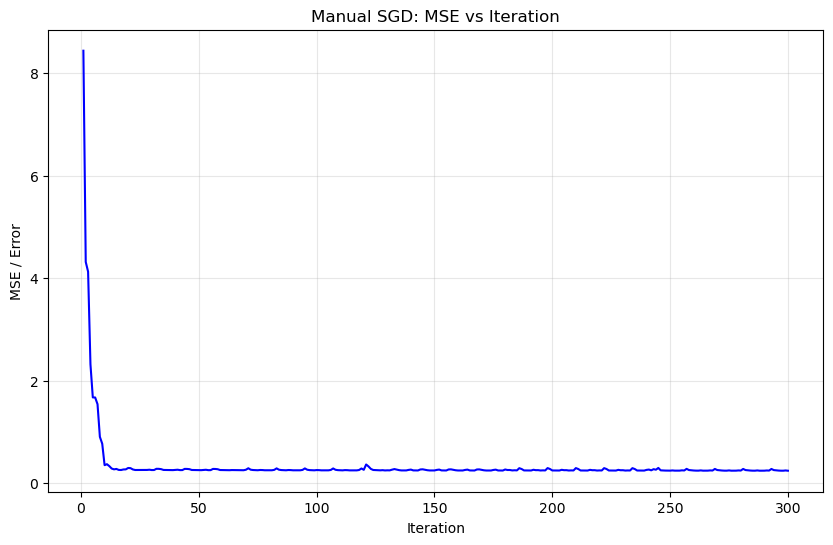

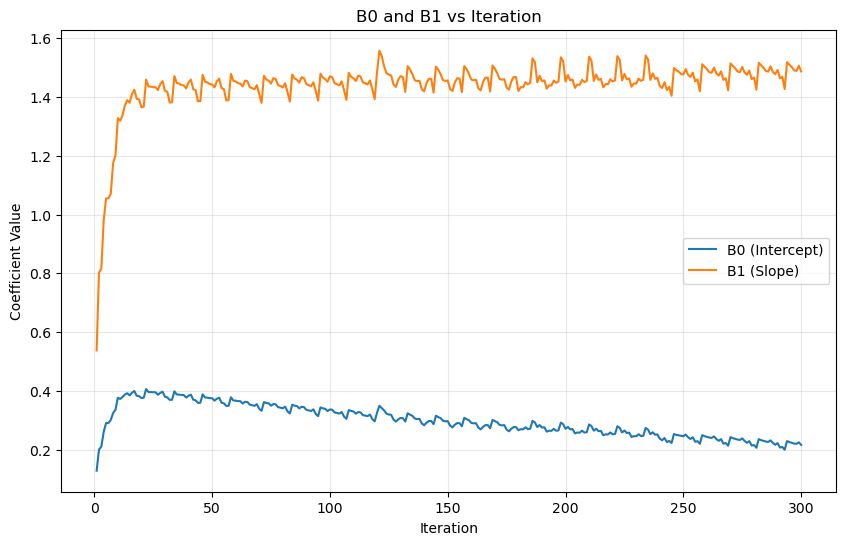

In [8]:
# PART (a)
# ERROR/MSE VS ITERATION

plt.figure(figsize=(10, 6))

plt.plot(iteration_history,error_history,color='blue',linewidth=1.5)

plt.xlabel("Iteration")
plt.ylabel("MSE / Error")
plt.title("Manual SGD: MSE vs Iteration")
plt.grid(True, alpha=0.3)

plt.show()

# PLOT B0 AND B1 VS ITERATION
plt.figure(figsize=(10, 6))
plt.plot(iteration_history,B0_history,label="B0 (Intercept)")
plt.plot(iteration_history,B1_history,label="B1 (Slope)")

plt.xlabel("Iteration")
plt.ylabel("Coefficient Value")
plt.title("B0 and B1 vs Iteration")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [23]:
# PART (b)
# SCIKIT-LEARN SGD REGRESSOR


sk_model = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=0.001,
    max_iter=60,
    tol=None,
    random_state=42,
    shuffle=True,
    fit_intercept=True
)

sk_model.fit(X.reshape(-1, 1), y)

sk_B0 = sk_model.intercept_[0]
sk_B1 = sk_model.coef_[0]

sk_predictions = sk_model.predict(X.reshape(-1, 1))

sk_mse = mean_squared_error(y, sk_predictions)
print("SCIKIT-LEARN SGD RESULTS")
print("========================================")

print(f"B0 = {sk_B0:.6f}")
print(f"B1 = {sk_B1:.6f}")
print(f"MSE = {sk_mse:.6f}")

print("\nRegression Equation:")
print("========================================")
print(f"Salary = {sk_B0:.6f} + {sk_B1:.6f} * Experience")

# COMPARE MANUAL SGD AND SCIKIT-LEARN

comparison = pd.DataFrame({
    'Method': ['Manual SGD', 'Scikit-learn SGD'],
    'B0': [B0, sk_B0],
    'B1': [B1, sk_B1],
    'MSE': [error_history[-1], sk_mse]
})

print("COMPARISON")
print("========================================")

print(comparison.to_string(index=False))

SCIKIT-LEARN SGD RESULTS
B0 = 0.422896
B1 = 1.416472
MSE = 0.256830

Regression Equation:
Salary = 0.422896 + 1.416472 * Experience
COMPARISON
          Method       B0       B1      MSE
      Manual SGD 0.215915 1.487488 0.240629
Scikit-learn SGD 0.422896 1.416472 0.256830


SCIKIT-LEARN APPROACH: BETA VS MSE
Best Beta = 1.42
Minimum MSE = 0.256750


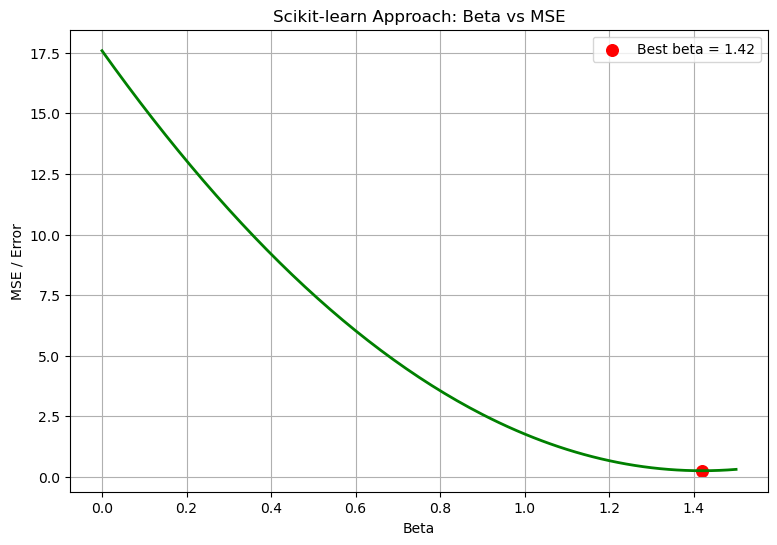

In [28]:
#PART (c)
#BETA VS MSE - SCIKIT-LEARN APPROACH
sk_beta_mse = []

for beta in beta_values:

    predictions = sk_B0 + beta * X

    mse = mean_squared_error(y, predictions)

    sk_beta_mse.append(mse)


sk_beta_mse = np.array(sk_beta_mse)

best_sk_index = np.argmin(sk_beta_mse)

best_sk_beta = beta_values[best_sk_index]
best_sk_mse = sk_beta_mse[best_sk_index]

print("SCIKIT-LEARN APPROACH: BETA VS MSE")

print(f"Best Beta = {best_sk_beta:.2f}")
print(f"Minimum MSE = {best_sk_mse:.6f}")

manual_beta_mse = []
manual_beta_mse = np.array(manual_beta_mse)
plt.figure(figsize=(9, 6))

plt.plot(beta_values,sk_beta_mse,color='green',linewidth=2)
plt.scatter(best_sk_beta,best_sk_mse,color='red',  s=70,
    label=f"Best beta = {best_sk_beta:.2f}"
)

plt.xlabel("Beta")
plt.ylabel("MSE / Error")
plt.title("Scikit-learn Approach: Beta vs MSE")
plt.legend()
plt.grid(True)

plt.show()

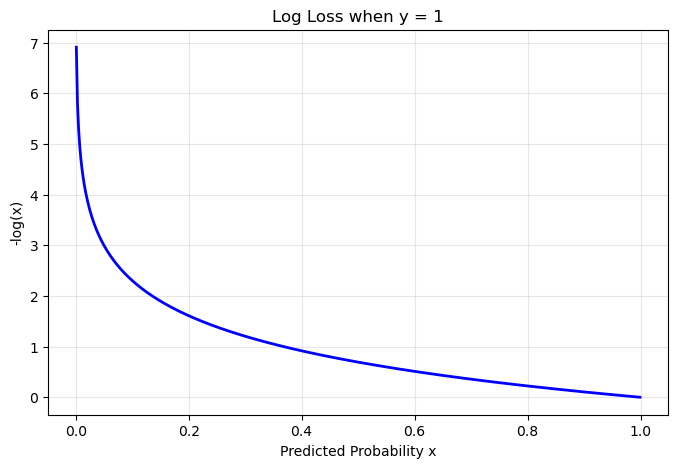

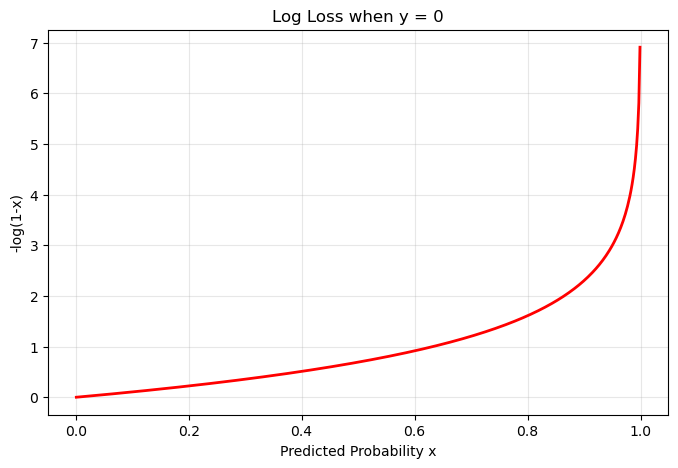

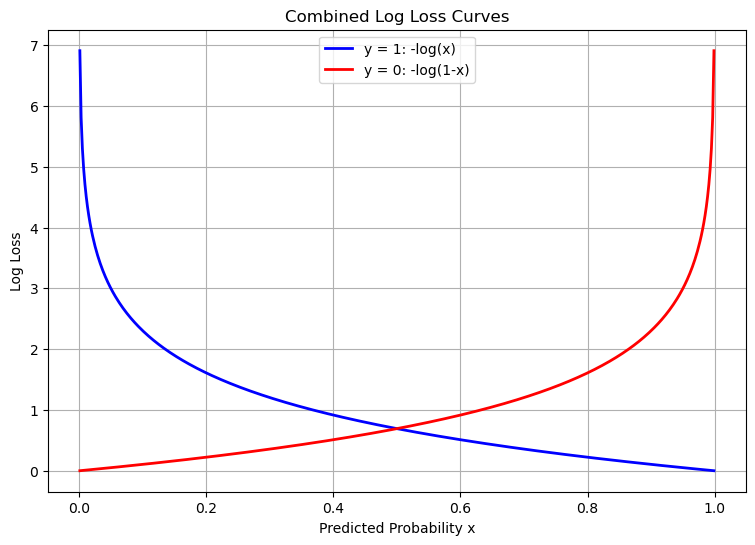

In [29]:
# PART (d)
# LOG LOSS CURVES

x = np.linspace(0.001, 0.999, 500)

loss_y1 = -np.log(x)
loss_y0 = -np.log(1 - x)

# y = 1

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    loss_y1,
    color='blue',
    linewidth=2
)

plt.xlabel("Predicted Probability x")
plt.ylabel("-log(x)")
plt.title("Log Loss when y = 1")
plt.grid(True, alpha=0.3)

plt.show()


# y = 0

plt.figure(figsize=(8, 5))
plt.plot(
    x,
    loss_y0,
    color='red',
    linewidth=2
)

plt.xlabel("Predicted Probability x")
plt.ylabel("-log(1-x)")
plt.title("Log Loss when y = 0")
plt.grid(True, alpha=0.3)

plt.show()

# COMBINED GRAPH
plt.figure(figsize=(9, 6))
plt.plot(x,loss_y1,color='blue',linewidth=2,label='y = 1: -log(x)')

plt.plot(x,loss_y0,color='red',linewidth=2,label='y = 0: -log(1-x)')

plt.xlabel("Predicted Probability x")
plt.ylabel("Log Loss")
plt.title("Combined Log Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

3.<br>
Consider positive and negative slope dataset given below. Apply simple linear regression with gradient
descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph
of slope(x-axis) vs MSE (y-axis) for both case separately.
<br>x = np.array([1, 2, 4, 3, 5])
<br>y = np.array([1, 3, 3, 2, 5]) # Positive slope
<br>x = np.array([1, 2, 3, 4, 5])
<br>y = np.array([10, 8, 6, 4, 2]) # Negative slope

In [30]:
# GRADIENT DESCENT FUNCTION
def gradient_descent(x, y, learning_rate=0.01, iterations=60):
    B0 = 0.0
    B1 = 0.0
    n = len(x)
    iteration_history = []
    B0_history = []
    B1_history = []
    mse_history = []

    for iteration in range(1, iterations + 1):
        y_pred = B0 + B1 * x
        error = y - y_pred
        dB0 = (-2 / n) * np.sum(error)
        dB1 = (-2 / n) * np.sum(x * error)
        B0 = B0 - learning_rate * dB0
        B1 = B1 - learning_rate * dB1
        y_pred_new = B0 + B1 * x
        # Calculate MSE
        mse = np.mean((y - y_pred_new) ** 2)
        # Store values
        iteration_history.append(iteration)
        B0_history.append(B0)
        B1_history.append(B1)
        mse_history.append(mse)
    return (np.array(iteration_history),np.array(B0_history),np.array(B1_history),np.array(mse_history))


learning_rate = 0.01
iterations = 60

# POSITIVE SLOPE DATASET
x_positive = np.array([1, 2, 4, 3, 5])
y_positive = np.array([1, 3, 3, 2, 5])


# NEGATIVE SLOPE DATASET
x_negative = np.array([1, 2, 3, 4, 5])
y_negative = np.array([10, 8, 6, 4, 2])

# RUN GRADIENT DESCENT - POSITIVE SLOPE
(iter_pos,B0_pos,B1_pos,mse_pos) = gradient_descent(x_positive,y_positive,learning_rate,iterations)
# RUN GRADIENT DESCENT - NEGATIVE SLOPE
(iter_neg,B0_neg,B1_neg,mse_neg) = gradient_descent(x_negative,y_negative,learning_rate,iterations)



print("POSITIVE SLOPE DATASET")
print(f"Final B0       = {B0_pos[-1]:.6f}")
print(f"Final B1       = {B1_pos[-1]:.6f}")
print(f"Final MSE      = {mse_pos[-1]:.6f}")

print("\nRegression equation:")
print(
    f"y = {B0_pos[-1]:.6f} + "
    f"{B1_pos[-1]:.6f}x"
)


print("\nNEGATIVE SLOPE DATASET")
print(f"Final B0       = {B0_neg[-1]:.6f}")
print(f"Final B1       = {B1_neg[-1]:.6f}")
print(f"Final MSE      = {mse_neg[-1]:.6f}")

print("\nRegression equation:")
print(
    f"y = {B0_neg[-1]:.6f} + "
    f"{B1_neg[-1]:.6f}x"
)

# VALUES AT DIFFERENT ITERATIONS
selected_iterations = [1, 5, 10, 20, 40, 60]
positive_table = pd.DataFrame({
    "Iteration": selected_iterations,
    "B0": [B0_pos[i - 1] for i in selected_iterations],
    "B1 (Slope)": [B1_pos[i - 1] for i in selected_iterations],
    "MSE": [mse_pos[i - 1] for i in selected_iterations]
})

negative_table = pd.DataFrame({
    "Iteration": selected_iterations,
    "B0": [B0_neg[i - 1] for i in selected_iterations],
    "B1 (Slope)": [B1_neg[i - 1] for i in selected_iterations],
    "MSE": [mse_neg[i - 1] for i in selected_iterations]
})

print("==")
print("POSITIVE SLOPE: VALUES AT DIFFERENT ITERATIONS")
print("==")
print(positive_table.to_string(index=False))
print("==")
print("NEGATIVE SLOPE: VALUES AT DIFFERENT ITERATIONS")
print("==")
print(negative_table.to_string(index=False))




POSITIVE SLOPE DATASET
Final B0       = 0.264770
Final B1       = 0.837457
Final MSE      = 0.483329

Regression equation:
y = 0.264770 + 0.837457x

NEGATIVE SLOPE DATASET
Final B0       = 2.484559
Final B1       = 0.635625
Final MSE      = 16.480523

Regression equation:
y = 2.484559 + 0.635625x
==
POSITIVE SLOPE: VALUES AT DIFFERENT ITERATIONS
==
 Iteration       B0  B1 (Slope)      MSE
         1 0.056000    0.200000 5.796736
         5 0.176341    0.625833 1.097421
        10 0.224071    0.787518 0.525841
        20 0.244093    0.839070 0.484550
        40 0.255288    0.840064 0.483811
        60 0.264770    0.837457 0.483329
==
NEGATIVE SLOPE: VALUES AT DIFFERENT ITERATIONS
==
 Iteration       B0  B1 (Slope)       MSE
         1 0.120000    0.280000 35.798400
         5 0.448035    0.856522 25.214143
        10 0.705918    1.039311 23.210449
        20 1.102595    1.012427 21.609492
        40 1.817706    0.820305 18.871387
        60 2.484559    0.635625 16.480523


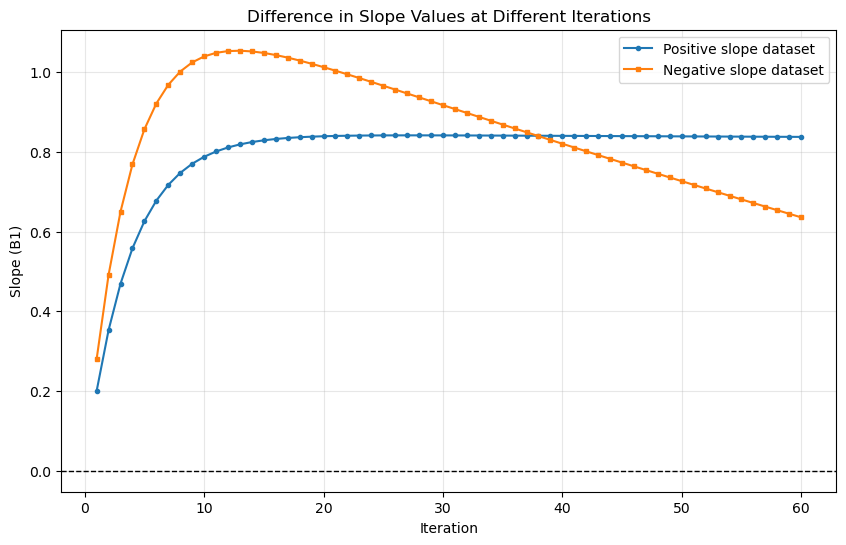

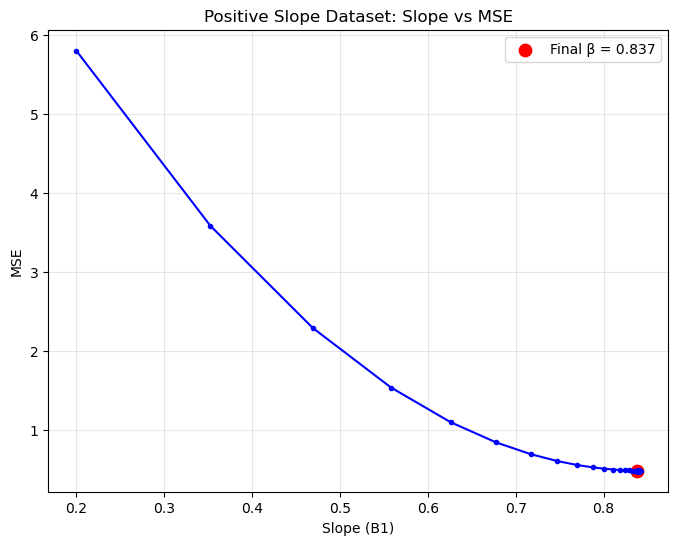

In [31]:
# PLOT 1: SLOPE VS ITERATION
# Compare positive and negative cases

plt.figure(figsize=(10, 6))
plt.plot(
    iter_pos,
    B1_pos,
    marker='o',
    markersize=3,
    label='Positive slope dataset'
)

plt.plot(iter_neg,B1_neg,marker='s',markersize=3,label='Negative slope dataset')
plt.axhline(
    0,
    color='black',
    linewidth=1,
    linestyle='--'
)

plt.xlabel("Iteration")
plt.ylabel("Slope (B1)")
plt.title("Difference in Slope Values at Different Iterations")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# PLOT 2: SLOPE VS MSE - POSITIVE CASE
plt.figure(figsize=(8, 6))

plt.plot(
    B1_pos,
    mse_pos,
    color='blue',
    marker='o',
    markersize=3
)

plt.scatter(
    B1_pos[-1],
    mse_pos[-1],
    color='red',
    s=80,
    label=f"Final β = {B1_pos[-1]:.3f}"
)

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Positive Slope Dataset: Slope vs MSE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

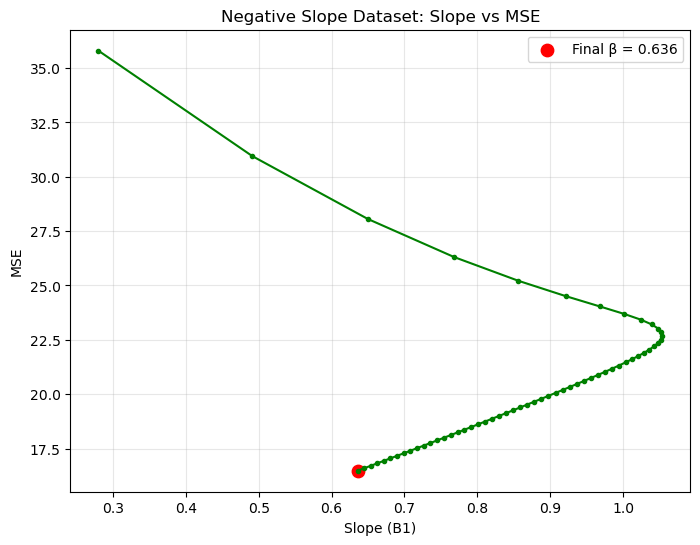

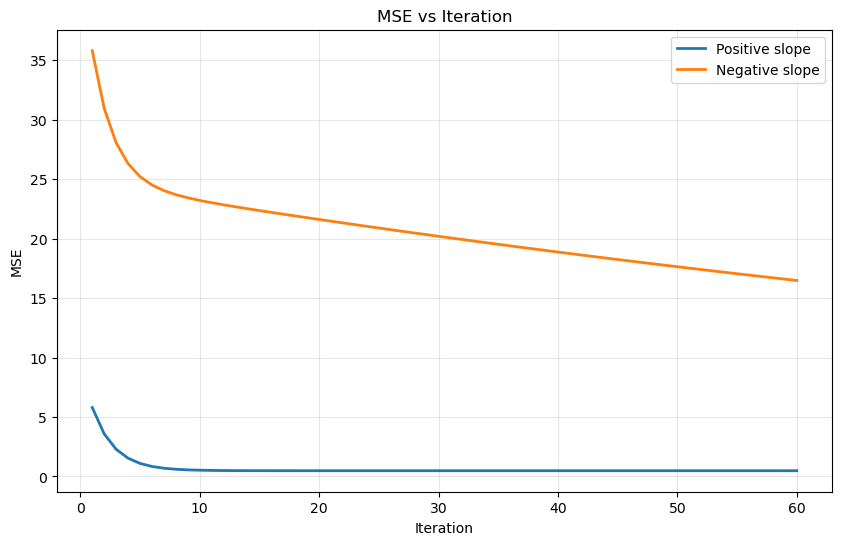

In [32]:
# PLOT 3: SLOPE VS MSE - NEGATIVE CASE
plt.figure(figsize=(8, 6))
plt.plot(B1_neg,mse_neg,color='green',marker='o',markersize=3)
plt.scatter(
    B1_neg[-1],
    mse_neg[-1],
    color='red',
    s=80,
    label=f"Final β = {B1_neg[-1]:.3f}"
)

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Negative Slope Dataset: Slope vs MSE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



# PLOT 4: MSE VS ITERATION
plt.figure(figsize=(10, 6))
plt.plot(iter_pos,mse_pos,label='Positive slope',linewidth=2)

plt.plot(
    iter_neg,
    mse_neg,
    label='Negative slope',
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE vs Iteration")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

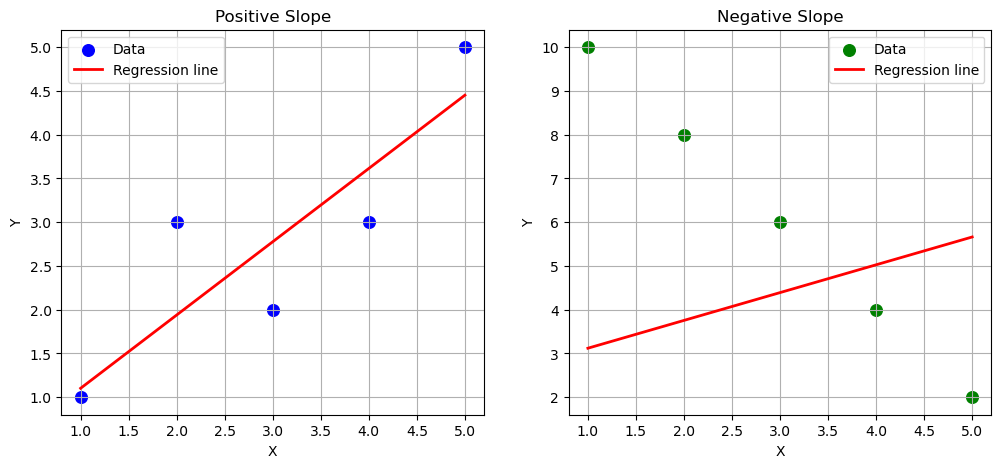

In [33]:
# PLOT 5: REGRESSION LINES

plt.figure(figsize=(12, 5))

# Positive case
plt.subplot(1, 2, 1)
plt.scatter(
    x_positive,
    y_positive,
    color='blue',
    s=70,
    label='Data'
)

x_line = np.linspace(min(x_positive),max(x_positive),100)
y_line_positive = (B0_pos[-1] +B1_pos[-1] * x_line)
plt.plot(x_line,y_line_positive,color='red',linewidth=2,label='Regression line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Positive Slope")
plt.legend()
plt.grid(True)


# Negative case
plt.subplot(1, 2, 2)
plt.scatter(
    x_negative,
    y_negative,
    color='green',
    s=70,
    label='Data'
)



x_line = np.linspace(
    min(x_negative),
    max(x_negative),
    100
)

y_line_negative = (
    B0_neg[-1] +
    B1_neg[-1] * x_line
)

plt.plot(x_line,y_line_negative,color='red',linewidth=2,label='Regression line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Negative Slope")
plt.legend()
plt.grid(True)

plt.show()

4.<br>
Consider positive and negative slope dataset given below. Apply logistic regression with gradient descent and
illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope(x-
axis) vs log-loss (y-axis) for both case separately.
<br>x = np.array([1, 2, 3, 4, 5])
<br>y = np.array([0, 0, 1, 1, 1]) # Positive slope
<br>x = np.array([1, 2, 3, 4, 5])
<br>y = np.array([1, 1, 0, 0, 0]) # Negative slope

In [34]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_log_loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def train_logistic_regression(x, y, lr=0.1, epochs=100):
    # Initialize parameters
    w = 0.0 # slope / weight
    b = 0.0 # intercept / bias
    n = len(x)
    
    weights_history = []
    loss_history = []
    
    for epoch in range(epochs):
        # Forward pass
        z = w * x + b
        y_pred = sigmoid(z)
        
        # Compute loss
        loss = compute_log_loss(y, y_pred)
        
        weights_history.append(w)
        loss_history.append(loss)
        
        # Gradients
        dw = (1/n) * np.dot((y_pred - y), x)
        db = (1/n) * np.sum(y_pred - y)
        
        # Update parameters
        w -= lr * dw
        b -= lr * db
        
    return weights_history, loss_history
print("All functions.")

All functions.


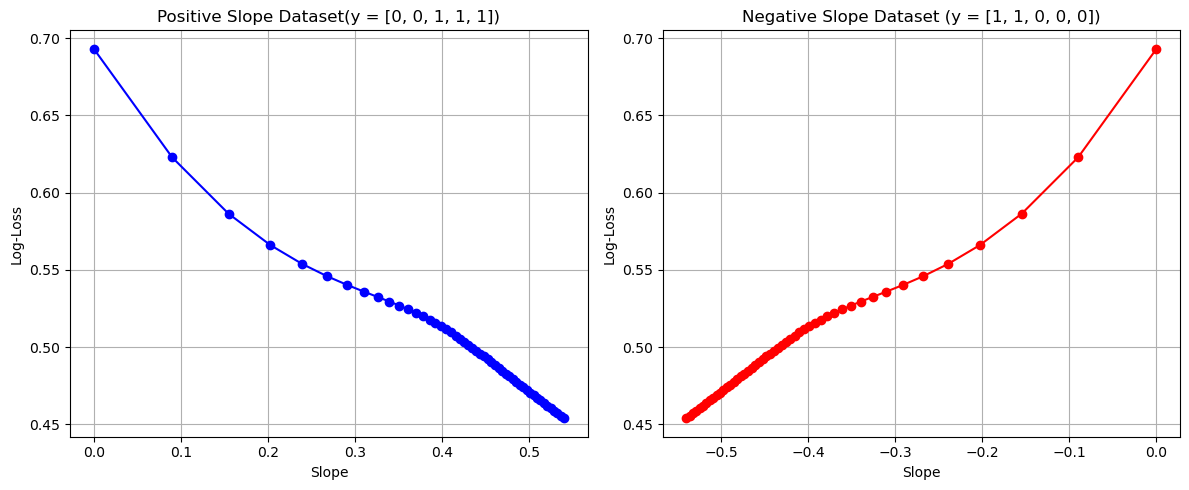

In [35]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y_pos = np.array([0, 0, 1, 1, 1], dtype=float) # Positive slope trend
y_neg = np.array([1, 1, 0, 0, 0], dtype=float) # Negative slope trend

epochs = 50
lr = 0.1
w_pos, loss_pos = train_logistic_regression(x, y_pos, lr, epochs)
w_neg, loss_neg = train_logistic_regression(x, y_neg, lr, epochs)

# Slope vs LogLoss
plt.figure(figsize=(12, 5))

# Positive Slope Dataset Plot
plt.subplot(1, 2, 1)
plt.plot(w_pos, loss_pos, marker='o', color='blue', linestyle='-')
plt.title('Positive Slope Dataset(y = [0, 0, 1, 1, 1])')
plt.xlabel('Slope')
plt.ylabel('Log-Loss')
plt.grid(True)

# Negative Slope Dataset Plot
plt.subplot(1, 2, 2)
plt.plot(w_neg, loss_neg, marker='o', color='red', linestyle='-')
plt.title('Negative Slope Dataset (y = [1, 1, 0, 0, 0])')
plt.xlabel('Slope')
plt.ylabel('Log-Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

# Addtional

1.<br> Apply scikit learn model for Simple Linear regression using SGD of the given Salary_Data.csvdataset, 
and arrive at different values of B0, B1 and error for varying iterations. 
Plot the graph ofepoch(X-axis) versus error(Y-axis).


Epochs   | B0 (Intercept)  | B1 (Coefficient) | MSE Error 
------------------------------------------------------------
1        | 0.0488          | 0.1525           | 16.7852   
2        | 0.0924          | 0.2889           | 13.3918   
5        | 0.1965          | 0.6152           | 6.8565    
10       | 0.3063          | 0.9623           | 2.3515    
20       | 0.3996          | 1.2687           | 0.4700    
50       | 0.4274          | 1.4115           | 0.2576    
100      | 0.4020          | 1.4248           | 0.2547    


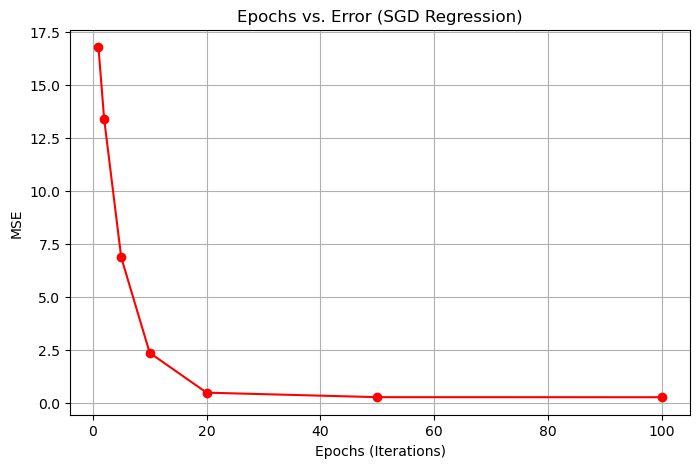

In [36]:
X = df[['experience']].values 
y = df['salary'].values

epochs_list = [1, 2, 5, 10, 20, 50, 100]
errors = []

print(
    f"{'Epochs':<8} | {'B0 (Intercept)':<15} | {'B1 (Coefficient)':<16} |"
    f" {'MSE Error':<10}"
)
print("-" * 60)

for epoch in epochs_list:
  sgd = SGDRegressor(
      max_iter=epoch, tol=None, learning_rate='constant', eta0=0.001, random_state=42
  )
  sgd.fit(X, y)

  b0 = sgd.intercept_[0]
  b1 = sgd.coef_[0]

  predictions = sgd.predict(X)
  error = mean_squared_error(y, predictions)
  errors.append(error)

  print(f"{epoch:<8} | {b0:<15.4f} | {b1:<16.4f} | {error:<10.4f}")


plt.figure(figsize=(8, 5))
plt.plot(epochs_list, errors, marker='o', color='red')
plt.title('Epochs vs. Error (SGD Regression)')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

2.<br>Apply simple linear regression with gradient descent method for x= {1, 2, 4, 3, 5} and y= {1, 3, 3, 2,
5} and plot Error (y axis) vs. Iteration (x axis) for 4 epochs (20 iterations). Manually work out the
values for the first epoch and verify the results in your notebook.

Iteration  | Epoch  | m          | b          | MSE Error 
-------------------------------------------------------
1          | 1      | 0.0000     | 0.0000     | 9.6000    
2          | 1      | 0.0100     | 0.0100     | 9.3458    
3          | 1      | 0.0694     | 0.0397     | 8.0608    
4          | 1      | 0.1767     | 0.0665     | 6.1117    
5          | 1      | 0.2188     | 0.0806     | 5.4116    
6          | 2      | 0.4101     | 0.1188     | 2.8893    
7          | 2      | 0.4148     | 0.1235     | 2.8277    
8          | 2      | 0.4557     | 0.1440     | 2.3781    
9          | 2      | 0.4971     | 0.1543     | 1.9965    
10         | 2      | 0.5077     | 0.1579     | 1.9032    
11         | 3      | 0.6229     | 0.1809     | 1.1060    
12         | 3      | 0.6248     | 0.1829     | 1.0929    
13         | 3      | 0.6562     | 0.1985     | 0.9219    
14         | 3      | 0.6633     | 0.2003     | 0.8894    
15         | 3      | 0.6575     | 0.1984     | 0.9161    


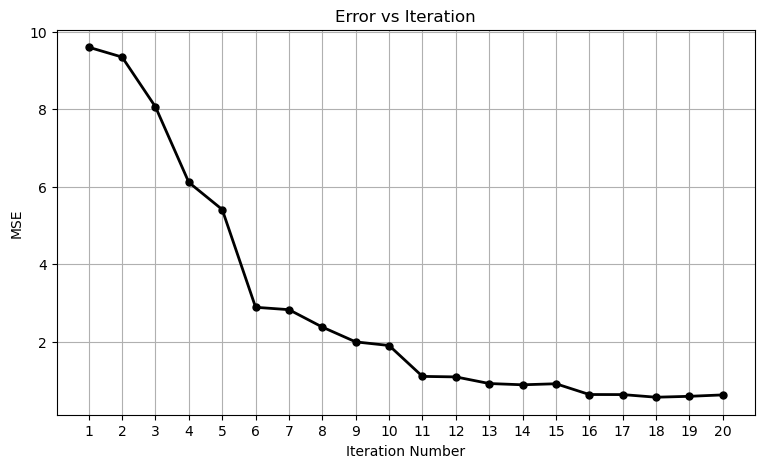

In [37]:
x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5])

m = 0.0
b = 0.0
learning_rate = 0.01
epochs = 4
n = len(x)

iterations = []
errors = []
iter_count = 0

print(f"{'Iteration':<10} | {'Epoch':<6} | {'m':<10} | {'b':<10} | {'MSE Error':<10}")
print("-" * 55)

for epoch in range(1, epochs + 1):
  for i in range(n):
    iter_count += 1
    xi = x[i]
    yi = y[i]


    y_pred_i = m * xi + b
    y_pred_all = m * x + b
    mse = np.mean((y - y_pred_all) ** 2)

    iterations.append(iter_count)
    errors.append(mse)

    print(
        f"{iter_count:<10} | {epoch:<6} | {m:<10.4f} | {b:<10.4f} |"
        f" {mse:<10.4f}"
    )
    dm = -(yi - y_pred_i) * xi
    db = -(yi - y_pred_i)

    m = m - learning_rate * dm
    b = b - learning_rate * db

plt.figure(figsize=(9, 5))
plt.plot(iterations,errors,marker='o',color='black',linestyle='-',linewidth=2,markersize=5)
plt.title('Error vs Iteration')
plt.xlabel('Iteration Number')
plt.ylabel('MSE')
plt.xticks(iterations)
plt.grid(True)
plt.show()